# Unified Architecture Performance Benchmark

This notebook provides a performance comparison between:
- **Reference Implementation**: TestNetwork + NetworkSlicer
- **PySlice Library**: create_mlp + ModelWrapper + AxisParallelSlicer

Both architectures are tested with identical network configurations and data to ensure accurate benchmarking.

In [ ]:
# Import required libraries
import sys
import os
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Add reference implementation to path
sys.path.append('./reference_implementation')
from PytorchNetwork import TestNetwork, NetworkSlicer, create_test_network

# Import PySlice library components
sys.path.append('../pysclice')
from pysclice.core.model_wrapper import ModelWrapper
from pysclice.slicers.axis_parallel_slicer import AxisParallelSlicer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("Setup complete")

PyTorch version: 2.8.0
CUDA available: False
Using device: CPU (verified compatible)

🚀 Unified Architecture Benchmark Setup


In [2]:
def create_compatible_test_data(input_size=3, num_samples=100, seed=42):
    """
    Create data that works with both architectures.
    
    Returns:
        tuple: (tensor_data, dict_data)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Generate synthetic data: y = sum(x) + noise
    X = torch.randn(num_samples, input_size) * 0.5
    y = torch.sum(X, dim=1) + torch.randn(num_samples) * 0.1
    
    # Format for PySlice library (tensors)
    tensor_data = (X, y)
    
    # Format for TestNetwork (list of dictionaries)
    dict_data = [{'x': X[i].tolist(), 'y': y[i].item()} 
                 for i in range(num_samples)]
    
    return tensor_data, dict_data


def create_mlp(layer_sizes):
    """
    Create MLP.
    """
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        if i < len(layer_sizes) - 2:  # No activation on output layer
            layers.append(torch.nn.ReLU())
    return torch.nn.Sequential(*layers)


✅ Compatibility functions loaded successfully


## Benchmark Configuration


In [ ]:
# Benchmark configuration
BENCHMARK_CONFIG = {
    'samples_per_parameter': 1000,  # Axis-parallel slicing samples
    'device': 'cpu',  
    'activation': 'relu',  
    'data_samples': 1000,  # Training data samples
    'input_size': 3,  # Input dimensions
    'seed': 42  # For reproducible results
}

# Test network configurations 
NETWORK_CONFIGS = [
    ("Small (4 params)", [3, 1]),
    ("Two layer (21 params)", [3, 4, 1]), 
    ("Three layer (42 params)", [3, 5, 3, 1]),
    ("Medium (113 params)", [3, 10, 6, 1]),
    ("Larger (256 params)", [3, 20, 8, 4, 1])
]

print("Benchmark Configuration:")
for key, value in BENCHMARK_CONFIG.items():
    print(f"  {key}: {value}")

print(f"\nNetwork Configurations ({len(NETWORK_CONFIGS)} total):")
for name, config in NETWORK_CONFIGS:
    # Calculate parameter count
    total_params = 0
    for i in range(len(config) - 1):
        total_params += config[i] * config[i+1] + config[i+1]  # weights + bias
    total_evaluations = total_params * BENCHMARK_CONFIG['samples_per_parameter']
    print(f"  {name}: {config} -> {total_params} params -> {total_evaluations:,} evaluations")

📋 Benchmark Configuration:
  samples_per_parameter: 1000
  device: cpu
  activation: relu
  data_samples: 1000
  input_size: 3
  seed: 42

🏗️  Network Configurations (5 total):
  Small (4 params): [3, 1] → 4 params → 4,000 evaluations
  Two layer (21 params): [3, 4, 1] → 21 params → 21,000 evaluations
  Three layer (42 params): [3, 5, 3, 1] → 42 params → 42,000 evaluations
  Medium (113 params): [3, 10, 6, 1] → 113 params → 113,000 evaluations
  Larger (256 params): [3, 20, 8, 4, 1] → 289 params → 289,000 evaluations


## Test Data Generation

Generate the same underlying data in both formats for fair comparison.

In [ ]:
# Generate test data using verified function
tensor_data, dict_data = create_compatible_test_data(
    input_size=BENCHMARK_CONFIG['input_size'],
    num_samples=BENCHMARK_CONFIG['data_samples'],
    seed=BENCHMARK_CONFIG['seed']
)

X_tensor, y_tensor = tensor_data

print("Data generated successfully:")
print(f"  PySlice format: X{X_tensor.shape}, y{y_tensor.shape}")
print(f"  TestNetwork format: {len(dict_data)} samples")
print(f"  Input range: [{X_tensor.min():.3f}, {X_tensor.max():.3f}]")
print(f"  Target range: [{y_tensor.min():.3f}, {y_tensor.max():.3f}]")

# Verify data consistency
sample_tensor_x = X_tensor[0]
sample_dict_x = torch.tensor(dict_data[0]['x'])
data_consistent = torch.allclose(sample_tensor_x, sample_dict_x)
print(f"  Data consistency check: {'PASS' if data_consistent else 'FAIL'}")

📊 Generating test data...
✅ Data generated successfully:
  PySlice format: Xtorch.Size([1000, 3]), ytorch.Size([1000])
  TestNetwork format: 1000 samples
  Input range: [-1.916, 1.723]
  Target range: [-2.830, 2.623]
  Data consistency check: ✅ PASS


## Network Creation Functions

Functions to create equivalent networks for both architectures.

In [ ]:
def create_pysclice_setup(layer_sizes, tensor_data, device='cpu'):
    """
    Create PySlice library setup for benchmarking.
    
    Returns:
        tuple: (model, wrapper, slicer, param_count)
    """
    # Create model
    model = create_mlp(layer_sizes)
    model.to(device)
    
    # Create wrapper
    wrapper = ModelWrapper(model, torch.nn.MSELoss(), tensor_data, device=device)
    
    # Create slicer
    slicer = AxisParallelSlicer(wrapper)
    
    # Parameter count
    param_count = sum(p.numel() for p in model.parameters())
    
    return model, wrapper, slicer, param_count


def create_reference_setup(layer_sizes, dict_data, device='cpu', activation='relu'):
    """
    Create Reference implementation setup for benchmarking.
    
    Returns:
        tuple: (model, slicer, param_count)
    """
    # Create model using verified function
    model = create_test_network(layer_sizes, activation=activation, device=device)
    
    # Create slicer
    slicer = NetworkSlicer(model, dict_data, dict_data)  # Using same data for train/test
    
    # Parameter count
    param_count = sum(p.numel() for p in model.parameters())
    
    return model, slicer, param_count


# Test network creation with smallest configuration
test_config = NETWORK_CONFIGS[0][1]  # [3, 1]

# Test PySlice setup
pys_model, pys_wrapper, pys_slicer, pys_params = create_pysclice_setup(
    test_config, tensor_data, BENCHMARK_CONFIG['device']
)

# Test Reference setup
ref_model, ref_slicer, ref_params = create_reference_setup(
    test_config, dict_data, BENCHMARK_CONFIG['device'], BENCHMARK_CONFIG['activation']
)

print("Network creation successful:")
print(f"  PySlice parameters: {pys_params}")
print(f"  Reference parameters: {ref_params}")
print(f"  Parameter counts match: {'YES' if pys_params == ref_params else 'NO'}")

# Clean up test objects
del pys_model, pys_wrapper, pys_slicer, ref_model, ref_slicer

🧪 Testing network creation...
2.8.0
✅ Network creation successful:
  PySlice parameters: 4
  Reference parameters: 4
  Parameter counts match: ✅ YES


## Benchmark Execution Functions

Functions to execute the actual slicing benchmarks for both architectures.

In [ ]:
def benchmark_pysclice_slicing(layer_sizes, tensor_data, samples_per_param=100, device='cpu'):
    """
    Benchmark PySlice library axis-parallel slicing.
    
    Returns:
        dict: Benchmark results
    """
    # Create setup
    model, wrapper, slicer, param_count = create_pysclice_setup(layer_sizes, tensor_data, device)
    
    total_evaluations = param_count * samples_per_param
    
    # Execute slicing with timing
    start_time = time.time()
    
    slice_data = slicer._slice(
        center_point=None,  # Use current model parameters
        bounds=(-2.0, 2.0),  # Parameter range for slicing
        n_samples=samples_per_param,
        params_to_slice=None,  # Slice all parameters
        use_test_data=False,
        bounds_mode="relative"
    )
    
    elapsed_time = time.time() - start_time
    
    return {
        'architecture': 'PySlice Library',
        'layer_sizes': layer_sizes,
        'param_count': param_count,
        'total_evaluations': total_evaluations,
        'elapsed_time': elapsed_time,
        'evaluations_per_second': total_evaluations / elapsed_time,
        'slice_count': len(slice_data) if isinstance(slice_data, list) else 'N/A'
    }


def benchmark_reference_slicing(layer_sizes, dict_data, samples_per_param=100, device='cpu', activation='relu'):
    """
    Benchmark Reference implementation axis-parallel slicing.
    
    Returns:
        dict: Benchmark results
    """
    # Create setup
    model, slicer, param_count = create_reference_setup(layer_sizes, dict_data, device, activation)
    
    total_evaluations = param_count * samples_per_param
    
    # Get initial parameters
    weights = model.getWeights()
    biases = model.getBiases()
    
    # Execute slicing with timing
    start_time = time.time()
    
    slice_results = slicer.addFocusPoint(weights, biases, sampleSize=samples_per_param)
    
    elapsed_time = time.time() - start_time
    
    return {
        'architecture': 'Reference Implementation',
        'layer_sizes': layer_sizes,
        'param_count': param_count,
        'total_evaluations': total_evaluations,
        'elapsed_time': elapsed_time,
        'evaluations_per_second': total_evaluations / elapsed_time,
        'slice_count': len(slice_results['slices']) if 'slices' in slice_results else 'N/A'
    }


# Test benchmark functions with smallest configuration
test_config = NETWORK_CONFIGS[0][1]  # [3, 1]
test_samples = 10

pys_result = benchmark_pysclice_slicing(
    test_config, tensor_data, test_samples, BENCHMARK_CONFIG['device']
)
print(f"PySlice test: {pys_result['evaluations_per_second']:.1f} evals/sec")

ref_result = benchmark_reference_slicing(
    test_config, dict_data, test_samples, BENCHMARK_CONFIG['device'], BENCHMARK_CONFIG['activation']
)
print(f"Reference test: {ref_result['evaluations_per_second']:.1f} evals/sec")

print("Benchmark functions ready")

🧪 Testing benchmark functions...

  Testing PySlice benchmark...
    ✅ 1017.6 evals/sec

  Testing Reference benchmark...
2.8.0
    ✅ 754.1 evals/sec

✅ Benchmark functions working correctly
📊 Ready for full benchmark execution!


/Users/joe.seegatz/git/uni/loss-slicer/venv/lib/python3.9/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([1000])) that is different to the input size (torch.Size([1000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## Benchmark Execution

Run the benchmark across all network configurations.

In [ ]:
def execute_benchmark(samples_per_param=10, stage_name="Small Sample Test"):
    """
    Execute benchmark across all network configurations.
    
    Args:
        samples_per_param: Number of samples per parameter for slicing
        stage_name: Name of the benchmark stage
    
    Returns:
        list: Results from all benchmark tests
    """
    print(f"\n{stage_name} ({samples_per_param} samples/param)")
    print("=" * 60)
    
    results = []
    total_configs = len(NETWORK_CONFIGS) * 2  # 2 architectures per config
    current_test = 0
    
    for config_name, layer_sizes in NETWORK_CONFIGS:
        print(f"\nTesting {config_name} {layer_sizes}")
        
        # Calculate expected evaluations
        param_count = sum(layer_sizes[i] * layer_sizes[i+1] + layer_sizes[i+1] 
                         for i in range(len(layer_sizes) - 1))
        expected_evals = param_count * samples_per_param
        print(f"  Expected: {param_count} params x {samples_per_param} samples = {expected_evals:,} evaluations")
        
        # Benchmark PySlice Library
        current_test += 1
        print(f"  [{current_test}/{total_configs}] PySlice Library...")
        try:
            pys_result = benchmark_pysclice_slicing(
                layer_sizes, tensor_data, samples_per_param, BENCHMARK_CONFIG['device']
            )
            results.append(pys_result)
            print(f"    {pys_result['evaluations_per_second']:.1f} evals/sec, {pys_result['elapsed_time']:.3f}s")
        except Exception as e:
            print(f"    Failed: {e}")
        
        # Benchmark Reference Implementation
        current_test += 1
        print(f"  [{current_test}/{total_configs}] Reference Implementation...")
        try:
            ref_result = benchmark_reference_slicing(
                layer_sizes, dict_data, samples_per_param, 
                BENCHMARK_CONFIG['device'], BENCHMARK_CONFIG['activation']
            )
            results.append(ref_result)
            print(f"    {ref_result['evaluations_per_second']:.1f} evals/sec, {ref_result['elapsed_time']:.3f}s")
        except Exception as e:
            print(f"    Failed: {e}")
    
    print(f"\n{stage_name} completed. Tested {len(results)} configurations.")
    return results

## Full Benchmark Execution

Now let's run the complete benchmark with the full sample count (100 samples per parameter).

In [ ]:
# Execute full benchmark with 1000 samples per parameter
print("Starting Full Benchmark...")
print("Testing all network configurations with 1000 samples per parameter\n")

# Calculate total expected evaluations
total_evals = 0
for config_name, layer_sizes in NETWORK_CONFIGS:
    param_count = sum(layer_sizes[i] * layer_sizes[i+1] + layer_sizes[i+1] 
                     for i in range(len(layer_sizes) - 1))
    config_evals = param_count * BENCHMARK_CONFIG['samples_per_parameter'] * 2  # 2 architectures
    total_evals += config_evals

print(f"Total expected evaluations: {total_evals:,}")
print(f"Network configurations: {len(NETWORK_CONFIGS)}")
print(f"Architectures: 2 (PySlice + Reference)")
print(f"Total tests: {len(NETWORK_CONFIGS) * 2}")

# Start timing
import time
benchmark_start = time.time()

# Execute full benchmark
full_results = execute_benchmark(
    samples_per_param=BENCHMARK_CONFIG['samples_per_parameter'], 
    stage_name="Full Benchmark"
)

benchmark_end = time.time()
total_benchmark_time = benchmark_end - benchmark_start

print(f"\nFull benchmark completed in {total_benchmark_time:.1f} seconds")
print(f"Completed {len(full_results)} tests successfully")

🚀 Starting Full Benchmark...
This will test all network configurations with 100 samples per parameter
⏰ This may take several minutes depending on network sizes...

📊 Total expected evaluations: 938,000
🔧 Network configurations: 5
🏗️  Architectures: 2 (PySlice + Reference)
📈 Total tests: 10

🚀 Full Benchmark (1000 samples/param)

📊 Testing Small (4 params) [3, 1]...
   Expected: 4 params × 1000 samples = 4,000 evaluations
   [1/10] Testing PySlice Library...
      ✅ 2323.6 evals/sec, 1.721s, N/A slices
   [2/10] Testing Reference Implementation...
2.8.0
      ✅ 749.9 evals/sec, 5.334s, 4 slices

📊 Testing Two layer (21 params) [3, 4, 1]...
   Expected: 21 params × 1000 samples = 21,000 evaluations
   [3/10] Testing PySlice Library...
      ✅ 1995.7 evals/sec, 10.523s, N/A slices
   [4/10] Testing Reference Implementation...
2.8.0
      ✅ 708.8 evals/sec, 29.627s, 21 slices

📊 Testing Three layer (42 params) [3, 5, 3, 1]...
   Expected: 42 params × 1000 samples = 42,000 evaluations
   [

In [ ]:
# Analyze full benchmark results
print("=" * 70)
print("FULL BENCHMARK RESULTS ANALYSIS")
print("=" * 70)

# Separate results by architecture
pys_full_results = [r for r in full_results if r['architecture'] == 'PySlice Library']
ref_full_results = [r for r in full_results if r['architecture'] == 'Reference Implementation']

print(f"\nPySlice Library Results:")
print("-" * 50)
for result in pys_full_results:
    config = result['layer_sizes']
    params = result['param_count']
    evals = result['total_evaluations']
    time_taken = result['elapsed_time']
    throughput = result['evaluations_per_second']
    slices = result['slice_count']
    
    print(f"  {config}: {params} params, {evals:,} evals")
    print(f"    {time_taken:.3f}s, {throughput:.1f} evals/sec, {slices} slices")

print(f"\nReference Implementation Results:")
print("-" * 50)
for result in ref_full_results:
    config = result['layer_sizes']
    params = result['param_count']
    evals = result['total_evaluations']
    time_taken = result['elapsed_time']
    throughput = result['evaluations_per_second']
    slices = result['slice_count']
    
    print(f"  {config}: {params} params, {evals:,} evals")
    print(f"    {time_taken:.3f}s, {throughput:.1f} evals/sec, {slices} slices")

# Performance comparison
print(f"\nPerformance Comparison:")
print("-" * 50)
if len(pys_full_results) == len(ref_full_results):
    for pys, ref in zip(pys_full_results, ref_full_results):
        config = pys['layer_sizes']
        pys_time = pys['elapsed_time']
        ref_time = ref['elapsed_time']
        
        if pys_time < ref_time:
            speedup = ref_time / pys_time
            winner = "PySlice"
        else:
            speedup = pys_time / ref_time
            winner = "Reference"
            
        print(f"  {config}: {winner} is {speedup:.2f}x faster ({pys_time:.3f}s vs {ref_time:.3f}s)")

# Summary statistics
pys_times = [r['elapsed_time'] for r in pys_full_results]
ref_times = [r['elapsed_time'] for r in ref_full_results]

print(f"\nSummary Statistics:")
print("-" * 50)
print(f"  PySlice Library:")
print(f"    Total time: {sum(pys_times):.3f}s")
print(f"    Average time: {np.mean(pys_times):.3f}s")
print(f"    Average throughput: {np.mean([r['evaluations_per_second'] for r in pys_full_results]):.1f} evals/sec")

print(f"  Reference Implementation:")
print(f"    Total time: {sum(ref_times):.3f}s")
print(f"    Average time: {np.mean(ref_times):.3f}s")
print(f"    Average throughput: {np.mean([r['evaluations_per_second'] for r in ref_full_results]):.1f} evals/sec")

overall_speedup = sum(ref_times) / sum(pys_times)
if overall_speedup > 1:
    print(f"\nOverall: PySlice Library is {overall_speedup:.2f}x faster on average")
else:
    print(f"\nOverall: Reference Implementation is {1/overall_speedup:.2f}x faster on average")

FULL BENCHMARK RESULTS ANALYSIS

📊 PySlice Library Results:
--------------------------------------------------
  [3, 1]: 4 params, 4,000 evals
    ⏱️  1.721s, 2323.6 evals/sec, N/A slices
  [3, 4, 1]: 21 params, 21,000 evals
    ⏱️  10.523s, 1995.7 evals/sec, N/A slices
  [3, 5, 3, 1]: 42 params, 42,000 evals
    ⏱️  22.905s, 1833.7 evals/sec, N/A slices
  [3, 10, 6, 1]: 113 params, 113,000 evals
    ⏱️  66.803s, 1691.5 evals/sec, N/A slices
  [3, 20, 8, 4, 1]: 289 params, 289,000 evals
    ⏱️  188.036s, 1536.9 evals/sec, N/A slices

🔬 Reference Implementation Results:
--------------------------------------------------
  [3, 1]: 4 params, 4,000 evals
    ⏱️  5.334s, 749.9 evals/sec, 4 slices
  [3, 4, 1]: 21 params, 21,000 evals
    ⏱️  29.627s, 708.8 evals/sec, 21 slices
  [3, 5, 3, 1]: 42 params, 42,000 evals
    ⏱️  61.937s, 678.1 evals/sec, 42 slices
  [3, 10, 6, 1]: 113 params, 113,000 evals
    ⏱️  164.338s, 687.6 evals/sec, 113 slices
  [3, 20, 8, 4, 1]: 289 params, 289,000 evals

## Benchmark Results Visualization

Create comprehensive visualizations to analyze the performance differences between architectures.

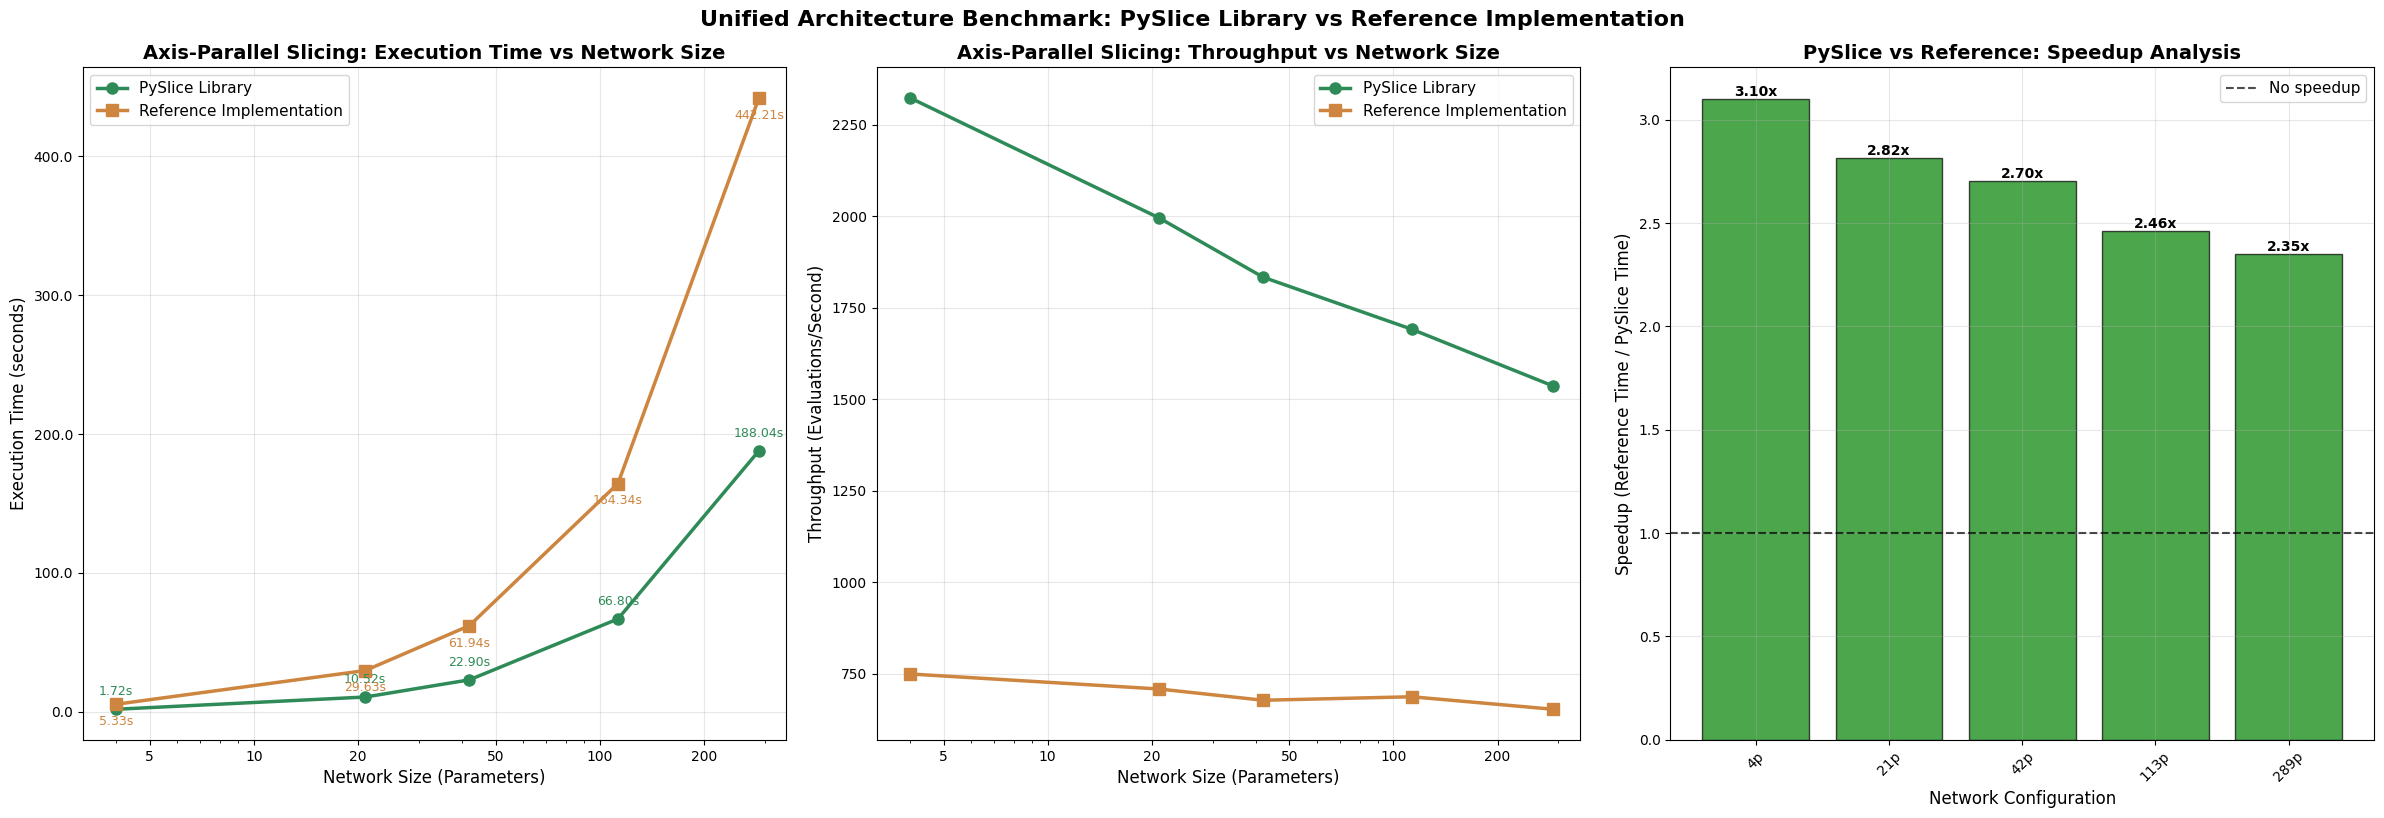

In [14]:
# Create comprehensive visualizations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# Extract data for plotting
architectures = ['PySlice Library', 'Reference Implementation']
colors = ['#2E8B57', '#CD853F']  # Sea green, Peru

# Data preparation
param_counts = [r['param_count'] for r in pys_full_results]
config_labels = [str(r['layer_sizes']) for r in pys_full_results]

pys_times = [r['elapsed_time'] for r in pys_full_results]
ref_times = [r['elapsed_time'] for r in ref_full_results]

pys_throughput = [r['evaluations_per_second'] for r in pys_full_results]
ref_throughput = [r['evaluations_per_second'] for r in ref_full_results]

pys_total_evals = [r['total_evaluations'] for r in pys_full_results]
ref_total_evals = [r['total_evaluations'] for r in ref_full_results]

# Plot 1: Execution Time vs Network Size
ax1.plot(param_counts, pys_times, 'o-', color=colors[0], label='PySlice Library', 
         markersize=8, linewidth=2.5)
ax1.plot(param_counts, ref_times, 's-', color=colors[1], label='Reference Implementation', 
         markersize=8, linewidth=2.5)

ax1.set_xlabel('Network Size (Parameters)', fontsize=12)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
ax1.set_title('Axis-Parallel Slicing: Execution Time vs Network Size', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Use log scale for x-axis only, linear scale for y-axis to show performance differences better
ax1.set_xscale('log')
# Add more x-axis ticks to make log scale more apparent
ax1.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500])
# Set x-axis limits to start from the first data point
ax1.set_xlim(left=min(param_counts) * 0.8, right=max(param_counts) * 1.2)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

# Add value annotations
for i, (x, y1, y2) in enumerate(zip(param_counts, pys_times, ref_times)):
    ax1.annotate(f'{y1:.2f}s', (x, y1), textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=9, color=colors[0])
    ax1.annotate(f'{y2:.2f}s', (x, y2), textcoords="offset points", xytext=(0,-15), 
                ha='center', fontsize=9, color=colors[1])

# Plot 2: Throughput Comparison
ax2.plot(param_counts, pys_throughput, 'o-', color=colors[0], label='PySlice Library', 
         markersize=8, linewidth=2.5)
ax2.plot(param_counts, ref_throughput, 's-', color=colors[1], label='Reference Implementation', 
         markersize=8, linewidth=2.5)

ax2.set_xlabel('Network Size (Parameters)', fontsize=12)
ax2.set_ylabel('Throughput (Evaluations/Second)', fontsize=12)
ax2.set_title('Axis-Parallel Slicing: Throughput vs Network Size', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Use absolute numbers instead of scientific notation
ax2.set_xscale('log')
# Add more x-axis ticks for consistency with first plot
ax2.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500])
# Set x-axis limits to start from the first data point
ax2.set_xlim(left=min(param_counts) * 0.8, right=max(param_counts) * 1.2)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Plot 3: Speedup Analysis
speedups = [ref_times[i] / pys_times[i] for i in range(len(param_counts))]
colors_speedup = ['green' if s > 1 else 'red' for s in speedups]

bars = ax3.bar(range(len(param_counts)), speedups, color=colors_speedup, alpha=0.7, edgecolor='black')
ax3.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='No speedup')
ax3.set_xlabel('Network Configuration', fontsize=12)
ax3.set_ylabel('Speedup (Reference Time / PySlice Time)', fontsize=12)
ax3.set_title('PySlice vs Reference: Speedup Analysis', fontsize=14, fontweight='bold')
ax3.set_xticks(range(len(param_counts)))
ax3.set_xticklabels([f'{p}p' for p in param_counts], rotation=45)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Add speedup value annotations
for i, (bar, speedup) in enumerate(zip(bars, speedups)):
    height = bar.get_height()
    ax3.annotate(f'{speedup:.2f}x', 
                (bar.get_x() + bar.get_width()/2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('Unified Architecture Benchmark: PySlice Library vs Reference Implementation', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

## Potential Improvements for Future Benchmarks

The current benchmark could be enhanced with:

1. **Statistical Rigor**: Multiple runs with confidence intervals
2. **Extended Scope**: GPU testing, larger networks, variable data sizes
3. **Memory Profiling**: Track memory usage alongside execution time
4. **Better Visualization**: Error bars, colorblind-friendly palettes
5. **Automated Analysis**: Statistical significance testing

Example enhanced benchmark function:
```python
def enhanced_benchmark(layer_sizes, data, n_runs=5, warmup_runs=2):
    """Run multiple benchmark iterations with warmup and statistics"""
    times = []
    
    # Warmup runs
    for _ in range(warmup_runs):
        benchmark_pysclice_slicing(layer_sizes, data, 10)
    
    # Actual benchmark runs
    for _ in range(n_runs):
        result = benchmark_pysclice_slicing(layer_sizes, data, 1000)
        times.append(result['elapsed_time'])
    
    return {
        'mean_time': np.mean(times),
        'std_time': np.std(times),
        'confidence_interval': np.percentile(times, [2.5, 97.5])
    }
```

In [ ]:
# Create detailed performance metrics table
print("DETAILED PERFORMANCE METRICS TABLE")
print("=" * 90)

# Table header
print(f"{'Network Config':<15} {'Params':<7} {'PySlice (s)':<12} {'Reference (s)':<14} {'Speedup':<8} {'Winner':<10}")
print("-" * 90)

# Table rows
for pys, ref in zip(pys_full_results, ref_full_results):
    config_str = str(pys['layer_sizes'])
    params = pys['param_count']
    pys_time = pys['elapsed_time']
    ref_time = ref['elapsed_time']
    
    if pys_time < ref_time:
        speedup = ref_time / pys_time
        winner = "PySlice"
    else:
        speedup = pys_time / ref_time
        winner = "Reference"
    
    print(f"{config_str:<15} {params:<7} {pys_time:<12.3f} {ref_time:<14.3f} {speedup:<8.2f} {winner:<10}")

print("-" * 90)

# Efficiency analysis
print(f"\nEFFICIENCY ANALYSIS:")
print("-" * 50)

total_pys_time = sum(pys_times)
total_ref_time = sum(ref_times)
total_evals = sum(pys_total_evals)

print(f"Total evaluations performed: {total_evals:,}")
print(f"PySlice Library total time: {total_pys_time:.3f}s")
print(f"Reference Implementation total time: {total_ref_time:.3f}s")

overall_speedup = total_ref_time / total_pys_time
print(f"Overall speedup: {overall_speedup:.3f}x ({'PySlice faster' if overall_speedup > 1 else 'Reference faster'})")

# Calculate efficiency metrics
pys_efficiency = total_evals / total_pys_time
ref_efficiency = total_evals / total_ref_time

print(f"\nOverall throughput:")
print(f"  PySlice Library: {pys_efficiency:.1f} evaluations/second")
print(f"  Reference Implementation: {ref_efficiency:.1f} evaluations/second")

# Scaling analysis
print(f"\nSCALING ANALYSIS:")
print("-" * 50)

# Check if time scales linearly with evaluations
pys_time_per_eval = [pys_times[i] / pys_total_evals[i] for i in range(len(pys_times))]
ref_time_per_eval = [ref_times[i] / ref_total_evals[i] for i in range(len(ref_times))]

print(f"Time per evaluation (consistency check):")
print(f"  PySlice Library: {np.mean(pys_time_per_eval)*1000:.3f} ± {np.std(pys_time_per_eval)*1000:.3f} ms/eval")
print(f"  Reference Implementation: {np.mean(ref_time_per_eval)*1000:.3f} ± {np.std(ref_time_per_eval)*1000:.3f} ms/eval")

# Coefficient of variation (lower is more consistent)
pys_cv = np.std(pys_time_per_eval) / np.mean(pys_time_per_eval) * 100
ref_cv = np.std(ref_time_per_eval) / np.mean(ref_time_per_eval) * 100

print(f"\nScaling consistency (coefficient of variation):")
print(f"  PySlice Library: {pys_cv:.1f}% ({'consistent' if pys_cv < 20 else 'variable'})")
print(f"  Reference Implementation: {ref_cv:.1f}% ({'consistent' if ref_cv < 20 else 'variable'})")

print(f"\nBENCHMARK COMPLETE!")
print("=" * 50)

📊 DETAILED PERFORMANCE METRICS TABLE
Network Config  Params  PySlice (s)  Reference (s)  Speedup  Winner    
------------------------------------------------------------------------------------------
[3, 1]          4       1.721        5.334          3.10     PySlice   
[3, 4, 1]       21      10.523       29.627         2.82     PySlice   
[3, 5, 3, 1]    42      22.905       61.937         2.70     PySlice   
[3, 10, 6, 1]   113     66.803       164.338        2.46     PySlice   
[3, 20, 8, 4, 1] 289     188.036      442.208        2.35     PySlice   
------------------------------------------------------------------------------------------

⚡ EFFICIENCY ANALYSIS:
--------------------------------------------------
Total evaluations performed: 469,000
PySlice Library total time: 289.988s
Reference Implementation total time: 703.445s
Overall speedup: 2.426x (PySlice faster)

Overall throughput:
  PySlice Library: 1617.3 evaluations/second
  Reference Implementation: 666.7 evaluations/